# Check Noise (pk): with vs without noise

Single tracer-field sanity check using `compute_statistics.py`.

- `tag_params = _p5_n10000`
- `tag_biasparams = _biasnoisenest_p9_n320000`
- `tag_noise = _noise_p5_n10000`


In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt

import sys
sys.path.append('/home/kstoreyf/muchisimocks/code')

import compute_statistics as cs
import data_loader
import paths
import utils

%load_ext autoreload
%autoreload 2

# Tags / indices to check
tag_params = '_p5_n10000'
tag_biasparams = '_biasnoisenest_p9_n320000'
tag_noise = '_noise_unit_p5_n10000'

idx_mock = 0
idx_noise = idx_mock
box_size = 1000.0

# Where the small parameter text files live in this repo
dir_params = '/home/kstoreyf/muchisimocks/data/params'

# Load cosmology for this mock index
params_df, param_dict_fixed = data_loader.load_cosmo_params(tag_params, dir_params=dir_params)
if params_df is None:
    param_dict = dict(param_dict_fixed)
else:
    param_dict = params_df.iloc[idx_mock].to_dict()
    param_dict.update(param_dict_fixed)
cosmo = utils.get_cosmo(param_dict)

# Load bias parameters (now includes noise parameters inside the dataframe)
biasparams_df, biasparams_dict_fixed = data_loader.load_bias_params(tag_biasparams, dir_params=dir_params, bx=None)
assert biasparams_df is not None

# Choose idx_bias:
# - nested bias: pick first row matching idx_cosmo==idx_mock
# - non-nested: idx_bias==0 by default
if 'idx_cosmo' in biasparams_df.columns:
    idx_bias_rows = biasparams_df[biasparams_df['idx_cosmo'] == idx_mock].index.tolist()
    assert len(idx_bias_rows) > 0, f'No bias rows found for idx_cosmo={idx_mock}'
    idx_bias = idx_bias_rows[0]
else:
    idx_bias = biasparams_df.index.tolist()[0]

print('idx_mock=', idx_mock, 'idx_noise=', idx_noise, 'idx_bias=', idx_bias)

# File paths for the Eulerian bias fields and noise field
dir_mocks = paths.mocks_lib_dir(tag_params)
subdir_prefix = 'mock' if 'p0' in tag_params else 'LH'
fn_fields = f'{dir_mocks}/{subdir_prefix}{idx_mock}/bias_fields_eul_deconvolved_{idx_mock}.npy'
fn_noise = paths.noise_fields_dir(tag_noise) / f'noise_field_n{idx_noise}.npy'

print('fn_fields=', fn_fields)
print('fn_noise =', fn_noise)

# Derive n_grid_orig from the stored bias-field file (also ensures normalization matches)
assert os.path.exists(fn_fields), f'Missing bias fields file: {fn_fields}'
bias_terms_eul_mmap = np.load(fn_fields, mmap_mode='r')
n_grid_orig = bias_terms_eul_mmap.shape[-1]
print('n_grid_orig=', n_grid_orig)

# Quick sanity: noise field existence (only needed for the noisy tracer field)
assert os.path.exists(fn_noise), f'Missing noise field file: {fn_noise}'


idx_mock= 0 idx_noise= 0 idx_bias= 0
fn_fields= /scratch/kstoreyf/muchisimocks/muchisimocks_lib_p5_n10000/LH0/bias_fields_eul_deconvolved_0.npy
fn_noise = /scratch/kstoreyf/muchisimocks/data/noise_fields/fields_noise_unit_p5_n10000/noise_field_n0.npy
n_grid_orig= 128


In [ ]:
# Diagnostics: confirm the noise-model branch and magnitudes
A_noise_dict = (biasparams_dict_fixed.copy() if biasparams_dict_fixed else {})
A_noise_dict.update(biasparams_df.loc[idx_bias].to_dict())
has_gaussian = 'An_gaussian' in A_noise_dict
if has_gaussian:
    print('make_tracer_field noise-model branch: additive (An_gaussian present)')
    print('An_gaussian =', A_noise_dict['An_gaussian'])
else:
    print('make_tracer_field noise-model branch: multiplicative (An_homog/An_b1/...)')
    A_noise_diag = [A_noise_dict[npm] for npm in utils.noiseparam_names_ordered]
    print('A_noise_diag =', A_noise_diag)
    print('max|A_noise_diag| =', np.max(np.abs(A_noise_diag)))

# Load the saved noise field once just to quantify its scale.
noise_field_diag = np.load(fn_noise)
print('noise_field_diag max|.| =', np.max(np.abs(noise_field_diag)))
print('noise_field_diag std =', float(np.std(noise_field_diag)))

# Build tracer field with noise
tracer_field_noise = cs.make_tracer_field(
    fn_fields=fn_fields,
    idx_bias=idx_bias,
    idx_noise=idx_noise,
    tag_noise=tag_noise,
    biasparams_df=biasparams_df,
    biasparams_dict_fixed=biasparams_dict_fixed,
    n_grid_orig=n_grid_orig,
)

# Build tracer field without noise
# We pass tag_noise=None so the tracer field is built from bias terms only.
tracer_field_noiseless = cs.make_tracer_field(
    fn_fields=fn_fields,
    idx_bias=idx_bias,
    idx_noise=idx_noise,  # ignored when tag_noise=None
    tag_noise=None,
    biasparams_df=biasparams_df,
    biasparams_dict_fixed=biasparams_dict_fixed,
    n_grid_orig=n_grid_orig,
)

print('tracer_field_noise  shape=', tracer_field_noise.shape)
print('tracer_field_noiseless shape=', tracer_field_noiseless.shape)
print('max|delta tracer| =', np.max(np.abs(tracer_field_noise - tracer_field_noiseless)))

noise_contrib = tracer_field_noise - tracer_field_noiseless
ratio_mean_abs = (np.mean(np.abs(noise_contrib)) / (np.mean(np.abs(tracer_field_noiseless)) + 1e-30))
print('mean|noise_contrib| / mean|tracer_noiseless| =', float(ratio_mean_abs))


make_tracer_field noise-model branch: multiplicative (An_homog/An_b1/...)
A_noise_diag = [0.0852146823187345, -1.539890347543659, 0.4850084822256137, -3.6874692638278153, -7.533955009972836]
max|A_noise_diag| = 7.533955009972836
noise_field_diag max|.| = 5.350106245219592
noise_field_diag std = 0.9998906606159854
make_tracer_field
/scratch/kstoreyf/muchisimocks/muchisimocks_lib_p5_n10000/LH0/bias_fields_eul_deconvolved_0.npy
0 0
_noise_unit_p5_n10000
Getting bias fields
/scratch/kstoreyf/muchisimocks/muchisimocks_lib_p5_n10000/LH0/bias_fields_eul_deconvolved_0.npy
(5, 128, 128, 128)
make_tracer_field
/scratch/kstoreyf/muchisimocks/muchisimocks_lib_p5_n10000/LH0/bias_fields_eul_deconvolved_0.npy
0 0
None
Getting bias fields
/scratch/kstoreyf/muchisimocks/muchisimocks_lib_p5_n10000/LH0/bias_fields_eul_deconvolved_0.npy
(5, 128, 128, 128)
tracer_field_noise  shape= (128, 128, 128)
tracer_field_noiseless shape= (128, 128, 128)
max|delta tracer| = 0.003901386370252549
mean|noise_contrib| / 

In [5]:
A_noise_dict

{'b1': 2.2348004205277068,
 'b2': -0.6425915007971321,
 'bs2': -0.0135978036462081,
 'bl': 7.606026447919444,
 'An_homog': 0.0852146823187345,
 'An_b1': -1.539890347543659,
 'An_b2': 0.4850084822256137,
 'An_bs2': -3.6874692638278153,
 'An_bl': -7.533955009972836,
 'idx_cosmo': 0.0,
 'nest_layer': 0.0}

In [3]:
# Compute pk for the same tracer field, once with noise and once without
pk_obj_noiseless = cs.compute_pk(
    tracer_field_noiseless, cosmo, box_size,
    n_threads=1, fn_stat=None,
)

pk_obj_noise = cs.compute_pk(
    tracer_field_noise, cosmo, box_size,
    n_threads=1, fn_stat=None,
)

k = pk_obj_noiseless['k']
pk0 = pk_obj_noiseless['pk']
pk1 = pk_obj_noise['pk']

print('Computed pk on', len(k), 'bins')
print('max(rel diff pk) =', np.max(np.abs(pk1 - pk0) / (np.abs(pk0) + 1e-30)))


Computing pk, using n_grid =  128


2026-03-18 18:46:25,470 bacco.statistics : Computing the power spectrum with ngrid=128 and interlacing=False
2026-03-18 18:46:27,145 bacco.statistics :  ...done in 1.67 s


bacco.power : boxsize 1000.000000; ngrid 128; nthreads 1; interlacing 0; deposit_method 1; log_binning 1; type 1; precision=single; correct_grid=0 (log=1); correct_sn=0
bacco.power : normalise_grid1=0 normalise_grid2=0 deconvolve_grid1=0 deconvolve_grid2=0
bacco.power : total mass 64 (grid1) 64 (grid2)
bacco.power : Doing FFTW
bacco.power: FFT took 0.014328 sec
bacco.power : Counting modes
bacco.power : done counting modes in 0.042378 sec
bacco.power : Starting Fourier loop 
bacco.power : done Fourier loop in 0.000140 secs
bacco.power : Deallocating arrays
Computing pk, using n_grid =  128


2026-03-18 18:46:27,146 bacco.statistics : Computing the power spectrum with ngrid=128 and interlacing=False
2026-03-18 18:46:27,214 bacco.statistics :  ...done in 0.068 s


bacco.power : boxsize 1000.000000; ngrid 128; nthreads 1; interlacing 0; deposit_method 1; log_binning 1; type 1; precision=single; correct_grid=0 (log=1); correct_sn=0
bacco.power : normalise_grid1=0 normalise_grid2=0 deconvolve_grid1=0 deconvolve_grid2=0
bacco.power : total mass 63.9787 (grid1) 63.9787 (grid2)
bacco.power : Doing FFTW
bacco.power: FFT took 0.013600 sec
bacco.power : Counting modes
bacco.power : done counting modes in 0.041868 sec
bacco.power : Starting Fourier loop 
bacco.power : done Fourier loop in 0.000135 secs
bacco.power : Deallocating arrays
Computed pk on 32 bins
max(rel diff pk) = 0.45469976622998043


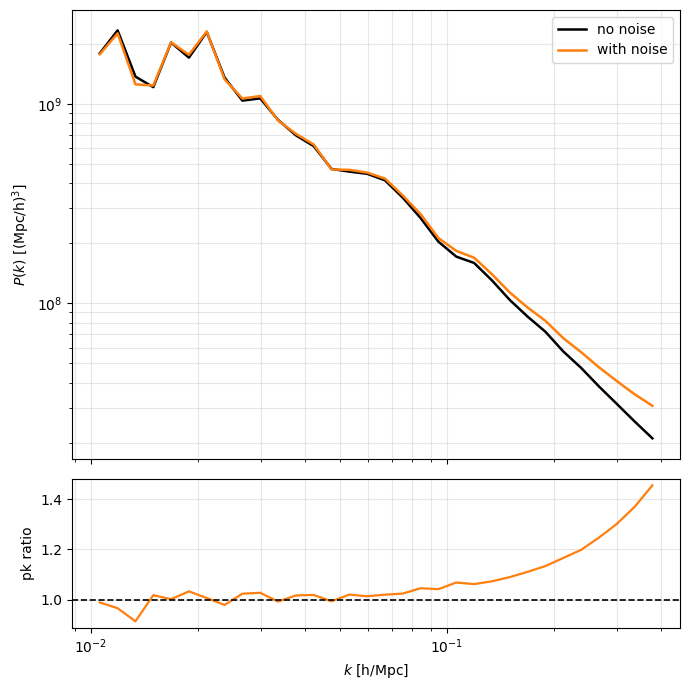

In [4]:
fig, (ax_pk, ax_ratio) = plt.subplots(2, 1, figsize=(7, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# pk curves
ax_pk.plot(k, pk0, label='no noise', c='k', lw=1.8)
ax_pk.plot(k, pk1, label='with noise', c='C1', lw=1.8)
ax_pk.set_xscale('log')
ax_pk.set_yscale('log')
ax_pk.set_ylabel(r'$P(k)$ [(Mpc/h)$^3$]')
ax_pk.legend()
ax_pk.grid(True, which='both', alpha=0.3)

# ratio
ratio = pk1 / (pk0 + 1e-30)
ax_ratio.plot(k, ratio, c='C1', lw=1.6)
ax_ratio.axhline(1.0, c='k', ls='--', lw=1.2)
ax_ratio.set_xscale('log')
ax_ratio.set_ylabel('pk ratio')
ax_ratio.set_xlabel(r'$k$ [h/Mpc]')
ax_ratio.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()
